In [23]:
%pip install kagglehub pandas matplotib numpy

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement matplotib (from versions: none)
ERROR: No matching distribution found for matplotib


In [29]:
import kagglehub
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
path = kagglehub.dataset_download("neurocipher/heartdisease")
print("Path to dataset files:", path)

Path to dataset files: C:\Users\tomas.ramirez\.cache\kagglehub\datasets\neurocipher\heartdisease\versions\1


In [ ]:
# Path obtenido desde kagglehub
DATASET_PATH = r"C:\Users\tomas.ramirez\.cache\kagglehub\datasets\neurocipher\heartdisease\versions\1"
# Ver archivos disponibles
import os
os.listdir(DATASET_PATH)


['Heart_Disease_Prediction.csv']

In [44]:
# Cargar dataset
df = pd.read_csv(os.path.join(DATASET_PATH, "Heart_Disease_Prediction.csv"))
df.head()


,Age,Sex,Chest pain type,BP,Cholesterol,FBS over 120,EKG results,Max HR,Exercise angina,ST depression,Slope of ST,Number of vessels fluro,Thallium,Heart Disease
0,70,1,4,130,322,0,2,109,0,2.4,2,3,3,Presence
1,67,0,3,115,564,0,2,160,0,1.6,2,0,7,Absence
2,57,1,2,124,261,0,0,141,0,0.3,1,0,7,Presence
3,64,1,4,128,263,0,0,105,1,0.2,2,1,7,Absence
4,74,0,2,120,269,0,2,121,1,0.2,1,1,3,Absence


## Feature selection + normalización

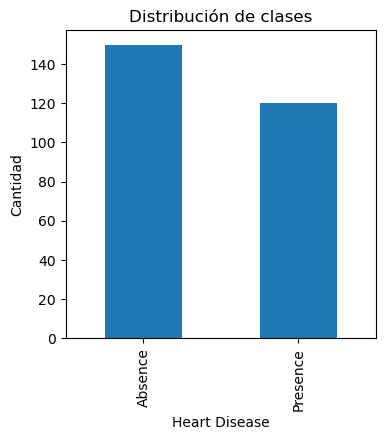

In [53]:
df['Heart Disease'].value_counts(normalize=True)

plt.figure(figsize=(4,4))
df['Heart Disease'].value_counts().plot(kind='bar')
plt.title("Distribución de clases")
plt.xlabel("Heart Disease")
plt.ylabel("Cantidad")
plt.show()


In [63]:
# --- Normalización (Z-score) ---
def normalize(X):
    mu = X.mean(axis=0)
    sigma = X.std(axis=0)
    return (X - mu) / sigma, mu, sigma

X_norm, mu, sigma = normalize(X)

# --- Stratified train/test split (70/30) ---
np.random.seed(42)

# índices por clase
idx_0 = np.where(y.flatten() == 0)[0]
idx_1 = np.where(y.flatten() == 1)[0]

# seleccionar aleatoriamente 70% para entrenamiento de cada clase
train_0 = np.random.choice(idx_0, int(0.7 * len(idx_0)), replace=False)
train_1 = np.random.choice(idx_1, int(0.7 * len(idx_1)), replace=False)

train_idx = np.concatenate([train_0, train_1])
test_idx = np.setdiff1d(np.arange(len(y)), train_idx)

X_train, y_train = X_norm[train_idx], y[train_idx]
X_test, y_test = X_norm[test_idx], y[test_idx]

print(f"Train samples: {len(X_train)}, Test samples: {len(X_test)}")

# Revisar distribución de clases en train/test
print("Train class distribution:\n", pd.Series(y_train.flatten()).value_counts())
print("Test class distribution:\n", pd.Series(y_test.flatten()).value_counts())


Train samples: 0, Test samples: 270
Train class distribution:
 Series([], Name: count, dtype: int64)
Test class distribution:
 Series([], Name: count, dtype: int64)
